In [40]:
!pip install catboost vowpalwabbit scipy

In [65]:
import numpy as np
import pandas as pd
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, f1_score,
                             precision_score, recall_score,
                             roc_curve)
from catboost import CatBoostClassifier, Pool
import vowpalwabbit
import scipy.special
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

Генерация датасета

In [66]:
PROFILES = {
    "Общий анализ крови": ["CBC", "HGB", "PLT"],
    "Биохимия":           ["ALT", "AST", "Creatinine"],
    "Гормоны":            ["TSH", "FT4", "Cortisol"],
    "Аллергология":       ["IgE", "Pollen", "DustMite"],
    "Коагулограмма":      ["APTT", "PT", "Fibrinogen"],
}

CODE_TO_PROFILE = {}
ALL_CODES = []
for prof, codes in PROFILES.items():
    for c in codes:
        CODE_TO_PROFILE[c] = prof
        ALL_CODES.append(c)
ALL_CODES = sorted(ALL_CODES)

CITIES = ["Москва", "СПб", "Екатеринбург", "Казань", "Новосибирск"]
AGE_GROUPS = ["18-30", "31-45", "46-60", "60+"]
GENDERS = ["М", "Ж"]
N_PATIENTS = 2000

patients = []
for pid in range(N_PATIENTS):
    age = np.random.choice(AGE_GROUPS)
    gender = np.random.choice(GENDERS)
    city = np.random.choice(CITIES)

    n_profiles = np.random.randint(1, 4)
    chosen_profiles = np.random.choice(
        list(PROFILES.keys()), size=n_profiles, replace=False
    )

    basket = []
    for prof in chosen_profiles:
        available = PROFILES[prof]
        n_take = np.random.randint(1, min(len(available), 3) + 1)
        taken = np.random.choice(available, size=n_take, replace=False)
        basket.extend(taken.tolist())

    if age in ["46-60", "60+"]:
        for prof in ["Биохимия", "Коагулограмма"]:
            if prof not in chosen_profiles and np.random.rand() < 0.3:
                extra = np.random.choice(PROFILES[prof])
                if extra not in basket:
                    basket.append(extra)

    if len(basket) < 2:
        remaining = [c for c in ALL_CODES if c not in basket]
        basket.append(np.random.choice(remaining))

    patients.append({
        "patient_id": pid,
        "age_group": age,
        "gender": gender,
        "city": city,
        "basket": list(set(basket)),
    })

patients_df = pd.DataFrame(patients)
print(f"Пациентов: {len(patients_df)}")
print(f"Средний размер корзины: " f"{patients_df['basket'].apply(len).mean():.1f}")
print(f"Распределение размеров корзин:")
print(patients_df["basket"].apply(len).value_counts().sort_index())

Пациентов: 2000
Средний размер корзины: 4.2
Распределение размеров корзин:
basket
2     484
3     386
4     304
5     306
6     245
7     156
8      83
9      33
10      3
Name: count, dtype: int64


Формирование обучающей выборки

In [67]:
def generate_training_data(patients_df, all_codes, code_to_profile, k=3, M=3, seed=42):
    # k - число положительных примеров на пациента
    # M - число отрицательных примеров на пациента

    rng = np.random.RandomState(seed)
    rows = []

    for _, pat in patients_df.iterrows():
        basket = pat["basket"]
        pid = pat["patient_id"]
        age = pat["age_group"]
        gender = pat["gender"]
        city = pat["city"]

        not_in_basket = [c for c in all_codes if c not in basket]

        # Положительные примеры
        n_pos = min(k, len(basket))
        pos_indices = rng.choice(len(basket), size=n_pos, replace=False)

        for idx in pos_indices:
            candidate = basket[idx]
            remaining = [s for s in basket if s != candidate]
            cand_profile = code_to_profile[candidate]
            n_same = sum(1 for s in remaining
                         if code_to_profile[s] == cand_profile)

            rows.append({
                "patient_id": pid,
                "age_group": age,
                "gender": gender,
                "city": city,
                "bucket_codes": remaining,
                "candidate_code": candidate,
                "candidate_profile": cand_profile,
                "n_services_total": len(remaining),
                "n_services_same_profile": n_same,
                "label": 1,
            })

        # Отрицательные примеры
        n_neg = min(M, len(not_in_basket))
        neg_indices = rng.choice(
            len(not_in_basket), size=n_neg, replace=False
        )

        for idx in neg_indices:
            candidate = not_in_basket[idx]
            cand_profile = code_to_profile[candidate]
            n_same = sum(1 for s in basket
                         if code_to_profile[s] == cand_profile)

            rows.append({
                "patient_id": pid,
                "age_group": age,
                "gender": gender,
                "city": city,
                "bucket_codes": basket,
                "candidate_code": candidate,
                "candidate_profile": cand_profile,
                "n_services_total": len(basket),
                "n_services_same_profile": n_same,
                "label": 0,
            })

    return pd.DataFrame(rows)


K_POS = 3
M_NEG = 3

gen_df = generate_training_data(
    patients_df, ALL_CODES, CODE_TO_PROFILE,
    k=K_POS, M=M_NEG, seed=SEED
)

print(f"Всего обучающих примеров: {len(gen_df)}")
print(f"Положительных (label=1): {gen_df['label'].sum()}")
print(f"Отрицательных (label=0): {(gen_df['label']==0).sum()}")

Всего обучающих примеров: 11516
Положительных (label=1): 5516
Отрицательных (label=0): 6000


Примеры записей

In [44]:
sample_cols = ["age_group", "gender", "bucket_codes",
               "candidate_code", "candidate_profile",
               "n_services_same_profile", "n_services_total", "label"]
print(gen_df[sample_cols].sample(8, random_state=SEED).to_string(index=False))

age_group gender                                            bucket_codes candidate_code candidate_profile  n_services_same_profile  n_services_total  label
    18-30      М                            [ALT, Creatinine, AST, APTT]            IgE      Аллергология                        0                 4      0
    18-30      Ж                                         [FT4, Cortisol]           APTT     Коагулограмма                        0                 2      0
    31-45      М                             [ALT, Creatinine, AST, TSH]            FT4           Гормоны                        1                 4      1
      60+      Ж [ALT, Fibrinogen, HGB, Creatinine, PLT, CBC, AST, APTT]       DustMite      Аллергология                        0                 8      0
      60+      Ж                             [Cortisol, ALT, Creatinine]            FT4           Гормоны                        1                 3      1
    18-30      Ж                          [FT4, Cortisol, HGB, C

Анализ данных

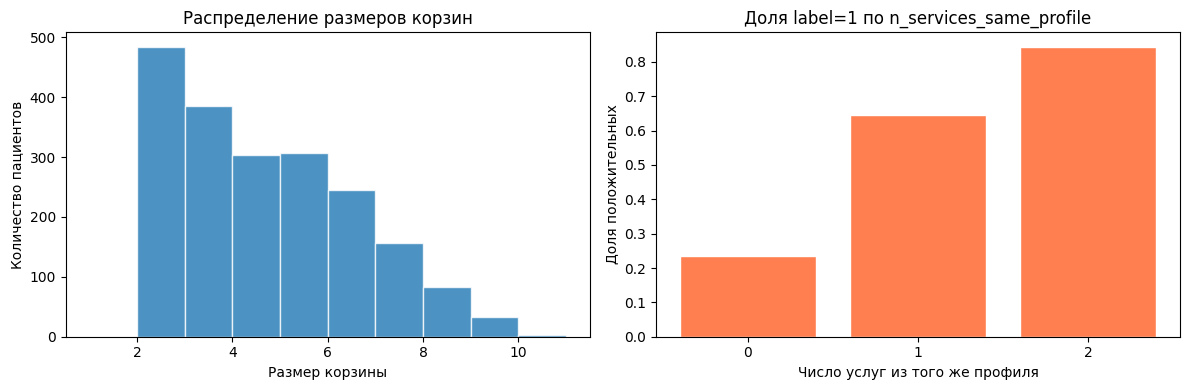

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Левый график - распределение размеров корзин
basket_sizes = patients_df["basket"].apply(len)
axes[0].hist(basket_sizes, bins=range(1, basket_sizes.max() + 2),
             edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Размер корзины")
axes[0].set_ylabel("Количество пациентов")
axes[0].set_title("Распределение размеров корзин")

# Правый график - доля label=1 по n_services_same_profile
rate = gen_df.groupby("n_services_same_profile")["label"].mean()
axes[1].bar(rate.index.astype(str), rate.values,
            color="coral", edgecolor="white")
axes[1].set_xlabel("Число услуг из того же профиля")
axes[1].set_ylabel("Доля положительных")
axes[1].set_title("Доля label=1 по n_services_same_profile")

plt.tight_layout()
plt.savefig("basket_analysis.png", dpi=150)
plt.show()

Разбиение данных

In [46]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    gen_df.drop(columns=["label"]),
    gen_df["label"],
    test_size=0.2,
    random_state=SEED,
    stratify=gen_df["label"],
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full,
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 7369, Val: 1843, Test: 2304


Модель Vowpal Wabbit

In [48]:
def to_vw_basket_line(row, label):
    # Преобразование записи в формат VW с тремя namespaces.
    lbl = 1 if label == 1 else -1

    # Namespace: description
    age_safe = str(row["age_group"]).replace("-", "_").replace("+", "plus")
    city_safe = str(row["city"]).replace(" ", "_")
    desc = (f"age_{age_safe} "
            f"gender_{row['gender']} "
            f"city_{city_safe} "
            f"n_total:{row['n_services_total']} "
            f"n_same:{row['n_services_same_profile']}")

    # Namespace: bucket
    bucket_codes = row["bucket_codes"]
    if isinstance(bucket_codes, str):
        bucket_codes = eval(bucket_codes)
    bucket = " ".join(bucket_codes) if bucket_codes else "EMPTY"

    # Namespace: candidate
    prof_safe = (str(row["candidate_profile"])
                 .replace(" ", "_")
                 .replace(",", ""))
    cand = f"{prof_safe} {row['candidate_code']}"

    return f"{lbl} |description {desc} |bucket {bucket} |candidate {cand}"


sample_row = X_train.iloc[0]
sample_label = y_train.iloc[0]
print("Пример строки VW:")
print(to_vw_basket_line(sample_row, sample_label))

vw = vowpalwabbit.Workspace(
    "--loss_function logistic "
    "--bit_precision 18 "
    "-q db -q bc "
    "--l2 1e-6 "
    "--passes 5 "
    "--cache_file /tmp/vw_basket_cache.tmp "
    "--kill_cache "
    "--quiet"
)

start_vw = time.time()
for idx in X_train.index:
    line = to_vw_basket_line(X_train.loc[idx], y_train.loc[idx])
    vw.learn(line)
time_vw = time.time() - start_vw

vw_raw = []
for idx in X_test.index:
    raw = vw.predict(to_vw_basket_line(X_test.loc[idx], y_test.loc[idx]))
    vw_raw.append(raw)
vw.finish()

vw_proba = scipy.special.expit(np.array(vw_raw))
vw_pred = (vw_proba >= 0.5).astype(int)

vw_auc = roc_auc_score(y_test, vw_proba)
vw_f1 = f1_score(y_test, vw_pred)
vw_prec = precision_score(y_test, vw_pred)
vw_rec = recall_score(y_test, vw_pred)

print(f"Результаты Vowpal Wabbit:")
print(f"AUC:       {vw_auc:.4f}")
print(f"F1:        {vw_f1:.4f}")
print(f"Precision: {vw_prec:.4f}")
print(f"Recall:    {vw_rec:.4f}")
print(f"Время:     {time_vw:.2f} с")

Пример строки VW:
1 |description age_60plus gender_М city_СПб n_total:3 n_same:0 |bucket HGB IgE PLT |candidate Коагулограмма Fibrinogen
Результаты Vowpal Wabbit:
AUC:       0.8360
F1:        0.7616
Precision: 0.7623
Recall:    0.7609
Время:     5.64 с


Модель CatBoost

In [56]:
def encode_for_catboost(df_subset, y_series, all_codes):
    # Multi-hot кодирование корзины
    rows = []
    for idx in df_subset.index:
        row = df_subset.loc[idx]
        bucket = row["bucket_codes"]
        if isinstance(bucket, str):
            bucket = eval(bucket)
        bucket_set = set(bucket)

        feat = {
            "age_group": row["age_group"],
            "gender": row["gender"],
            "city": row["city"],
            "candidate_code": row["candidate_code"],
            "candidate_profile": row["candidate_profile"],
            "n_services_total": row["n_services_total"],
            "n_services_same_profile": row["n_services_same_profile"],
        }
        for code in all_codes:
            feat[f"in_{code}"] = 1 if code in bucket_set else 0

        feat["target"] = y_series.loc[idx]
        rows.append(feat)

    result = pd.DataFrame(rows)
    return result


train_cb_df = encode_for_catboost(X_train, y_train, ALL_CODES)
val_cb_df = encode_for_catboost(X_val, y_val, ALL_CODES)
test_cb_df = encode_for_catboost(X_test, y_test, ALL_CODES)

FEATURE_COLS_CB = [c for c in train_cb_df.columns if c != "target"]
CAT_COLS_CB = ["age_group", "gender", "city",
               "candidate_code", "candidate_profile"]

X_tr_cb = train_cb_df[FEATURE_COLS_CB]
y_tr_cb = train_cb_df["target"]
X_va_cb = val_cb_df[FEATURE_COLS_CB]
y_va_cb = val_cb_df["target"]
X_te_cb = test_cb_df[FEATURE_COLS_CB]
y_te_cb = test_cb_df["target"]


cat_indices = [X_tr_cb.columns.get_loc(c) for c in CAT_COLS_CB]

train_pool = Pool(X_tr_cb, y_tr_cb, cat_features=cat_indices)
val_pool = Pool(X_va_cb, y_va_cb, cat_features=cat_indices)
test_pool = Pool(X_te_cb, y_te_cb, cat_features=cat_indices)

cb_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=SEED,
    verbose=100,
)

start_cb = time.time()
cb_model.fit(train_pool, eval_set=val_pool, use_best_model=True)
time_cb = time.time() - start_cb

cb_proba = cb_model.predict_proba(test_pool)[:, 1]
cb_pred = cb_model.predict(test_pool)

cb_auc = roc_auc_score(y_te_cb, cb_proba)
cb_f1 = f1_score(y_te_cb, cb_pred)
cb_prec = precision_score(y_te_cb, cb_pred)
cb_rec = recall_score(y_te_cb, cb_pred)

print(f"Результаты CatBoost:")
print(f"AUC:       {cb_auc:.4f}")
print(f"F1:        {cb_f1:.4f}")
print(f"Precision: {cb_prec:.4f}")
print(f"Recall:    {cb_rec:.4f}")
print(f"Время:     {time_cb:.2f} с")

0:	test: 0.8565119	best: 0.8565119 (0)	total: 38ms	remaining: 19s
100:	test: 0.8742285	best: 0.8744196 (81)	total: 1.53s	remaining: 6.04s
200:	test: 0.8747145	best: 0.8751829 (170)	total: 2.85s	remaining: 4.24s
300:	test: 0.8743040	best: 0.8751829 (170)	total: 5.74s	remaining: 3.8s
400:	test: 0.8748809	best: 0.8751829 (170)	total: 7.39s	remaining: 1.82s
499:	test: 0.8746602	best: 0.8751829 (170)	total: 8.87s	remaining: 0us

bestTest = 0.875182852
bestIteration = 170

Shrink model to first 171 iterations.
Результаты CatBoost:
AUC:       0.8777
F1:        0.8092
Precision: 0.7897
Recall:    0.8297
Время:     9.02 с


ROC-кривые

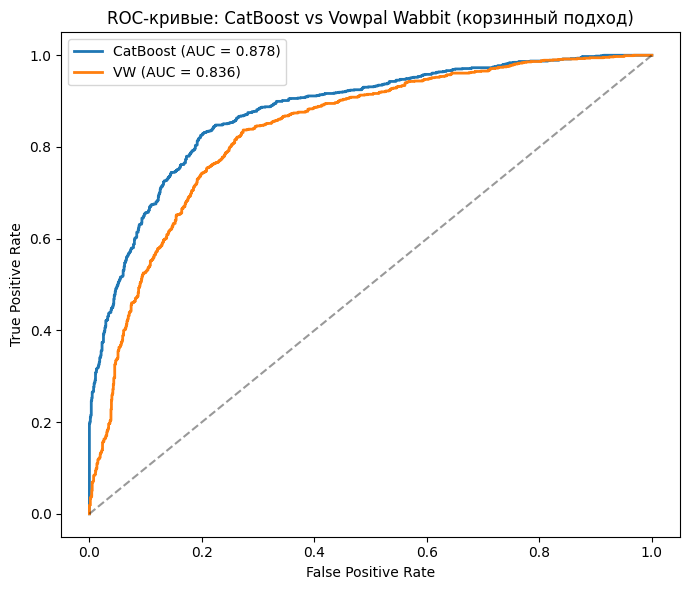

In [58]:
fpr_cb, tpr_cb, _ = roc_curve(y_te_cb, cb_proba)
fpr_vw, tpr_vw, _ = roc_curve(y_test, vw_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr_cb, tpr_cb,
         label=f"CatBoost (AUC = {cb_auc:.3f})", linewidth=2)
plt.plot(fpr_vw, tpr_vw,
         label=f"VW (AUC = {vw_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые: CatBoost vs Vowpal Wabbit (корзинный подход)")
plt.legend()
plt.tight_layout()
plt.savefig("basket_roc.png", dpi=150)
plt.show()

 Сводная таблица

In [59]:
results = pd.DataFrame({
    "Метрика": ["AUC", "F1", "Precision", "Recall", "Время обучения, с"],
    "CatBoost": [f"{cb_auc:.4f}", f"{cb_f1:.4f}",
                 f"{cb_prec:.4f}", f"{cb_rec:.4f}", f"{time_cb:.2f}"],
    "Vowpal Wabbit": [f"{vw_auc:.4f}", f"{vw_f1:.4f}",
                      f"{vw_prec:.4f}", f"{vw_rec:.4f}", f"{time_vw:.2f}"],
})
print(results.to_string(index=False))

          Метрика CatBoost Vowpal Wabbit
              AUC   0.8777        0.8360
               F1   0.8092        0.7616
        Precision   0.7897        0.7623
           Recall   0.8297        0.7609
Время обучения, с     9.02          5.64


Рекомендации для отдельного пациента

In [63]:
sample_patient = patients_df[
    patients_df["basket"].apply(len) >= 4
].iloc[339]

print(f"Пациент {sample_patient['patient_id']}: "
      f"{sample_patient['age_group']}, "
      f"{sample_patient['gender']}, "
      f"{sample_patient['city']}")
print(f"Корзина: {sample_patient['basket']}")

basket = sample_patient["basket"]
candidates = [c for c in ALL_CODES if c not in basket]

cand_rows = []
for cand_code in candidates:
    cand_profile = CODE_TO_PROFILE[cand_code]
    n_same = sum(1 for s in basket
                 if CODE_TO_PROFILE[s] == cand_profile)
    cand_rows.append({
        "patient_id": sample_patient["patient_id"],
        "age_group": sample_patient["age_group"],
        "gender": sample_patient["gender"],
        "city": sample_patient["city"],
        "bucket_codes": basket,
        "candidate_code": cand_code,
        "candidate_profile": cand_profile,
        "n_services_total": len(basket),
        "n_services_same_profile": n_same,
        "label": 0,
    })

cand_df = pd.DataFrame(cand_rows)

# Предсказание CatBoost
cand_cb = encode_for_catboost(
    cand_df.drop(columns=["label"]),
    pd.Series([0]*len(cand_df), index=cand_df.index),
    ALL_CODES
)
cand_pool = Pool(cand_cb[FEATURE_COLS_CB], cat_features=cat_indices)
scores = cb_model.predict_proba(cand_pool)[:, 1]

recs = (pd.DataFrame({
    "Профиль": cand_df["candidate_profile"].values,
    "Услуга": cand_df["candidate_code"].values,
    "n_same": cand_df["n_services_same_profile"].values,
    "P(комплементарность)": scores,
}).sort_values("P(комплементарность)", ascending=False))

print(f"\nУже в корзине:")
for s in basket:
    print(f"  [{CODE_TO_PROFILE[s]}] {s}")

print(f"\nТоп-5 рекомендаций:")
print(recs.head(5).to_string(index=False))

Пациент 619: 18-30, М, Казань
Корзина: ['Fibrinogen', 'HGB', 'IgE', 'DustMite', 'PLT', 'APTT']

Уже в корзине:
  [Коагулограмма] Fibrinogen
  [Общий анализ крови] HGB
  [Аллергология] IgE
  [Аллергология] DustMite
  [Общий анализ крови] PLT
  [Коагулограмма] APTT

Топ-5 рекомендаций:
           Профиль Услуга  n_same  P(комплементарность)
      Аллергология Pollen       2              0.802933
Общий анализ крови    CBC       2              0.802748
     Коагулограмма     PT       2              0.790614
          Биохимия    AST       0              0.098111
          Биохимия    ALT       0              0.096267
